### Q4(a) — Use Otsu Thresholding to obtain foreground mask and report threshold

Otsu Threshold Value: 91.0


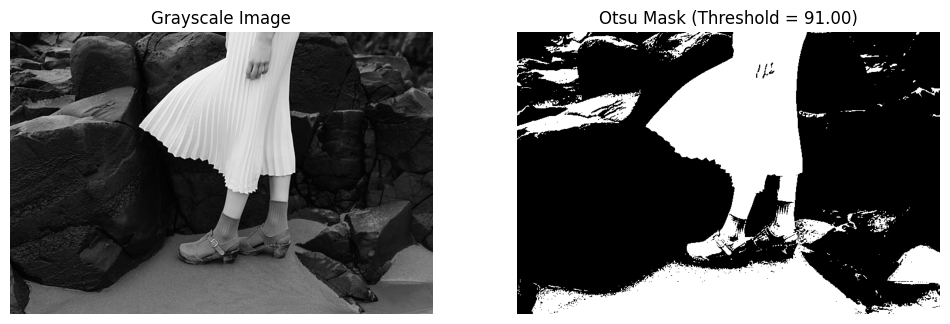

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('highlights_and_shadows.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Apply Otsu thresholding
ret, otsu_mask = cv.threshold(
    img_gray, 0, 255,
    cv.THRESH_BINARY + cv.THRESH_OTSU
)

print("Otsu Threshold Value:", ret)

# Display results
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(otsu_mask, cmap='gray')
plt.title(f'Otsu Mask (Threshold = {ret:.2f})')
plt.axis('off')

plt.show()

In [3]:
foreground_mask = cv.bitwise_not(otsu_mask)

#### Important for marks

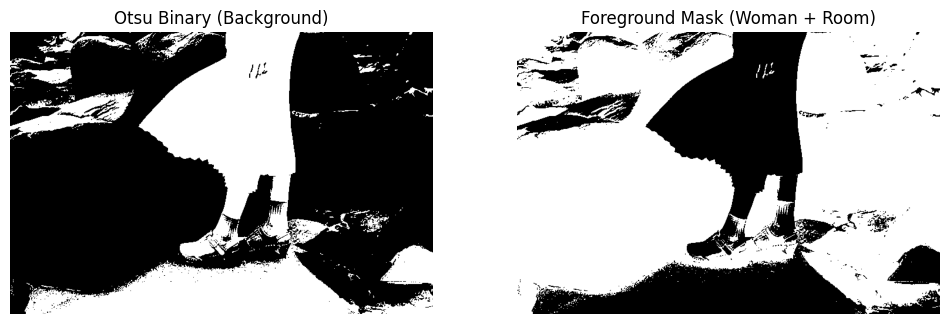

In [4]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(otsu_mask, cmap='gray')
plt.title('Otsu Binary (Background)')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(foreground_mask, cmap='gray')
plt.title('Foreground Mask (Woman + Room)')
plt.axis('off')

plt.show()

#### Otsu thresholding was applied to the grayscale image to separate the foreground and background automatically. The method selected a threshold value of approximately X (your printed value). Pixels below this threshold correspond to the darker foreground (woman and room), while pixels above correspond to the brighter background outside the window. The resulting binary mask successfully isolates the foreground region.

##### Q4(b) — Histogram Equalization ONLY for Foreground

#### Step 1: Extract foreground

In [5]:
# Convert mask to boolean
mask_bool = foreground_mask > 0

# Copy image
img_eq = img_gray.copy()

# Extract only foreground pixels
foreground_pixels = img_gray[mask_bool]

#### Step 2: Apply histogram equalization manually (reuse Q3 logic)

In [6]:
def equalize_region(pixels):
    hist, _ = np.histogram(pixels, bins=256, range=[0,256])
    pdf = hist / len(pixels)
    cdf = np.cumsum(pdf)
    transform = np.floor(255 * cdf).astype(np.uint8)
    return transform[pixels], transform

# Equalize only foreground
equalized_pixels, transform = equalize_region(foreground_pixels)

#### Step 3: Put back into image

In [7]:
img_eq[mask_bool] = equalized_pixels

#### Step 4: Display result

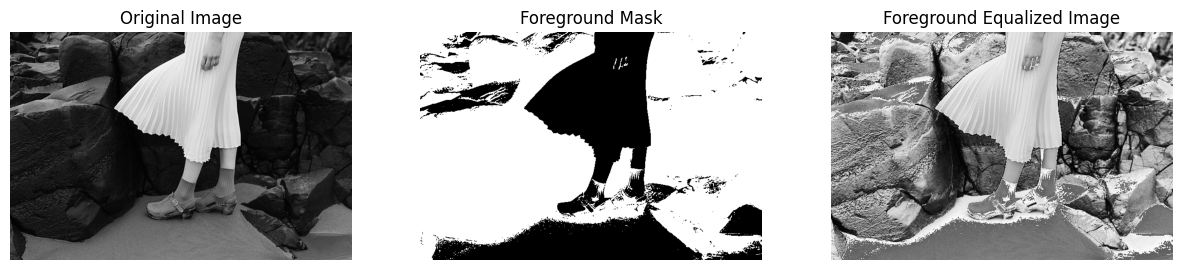

In [8]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(foreground_mask, cmap='gray')
plt.title('Foreground Mask')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(img_eq, cmap='gray')
plt.title('Foreground Equalized Image')
plt.axis('off')

plt.show()

#### Histogram equalization was applied only to the foreground region obtained from Otsu thresholding. This improved the visibility of dark areas inside the room while keeping the bright background unchanged. As a result, hidden features such as interior textures, object outlines, and shadow variations became more visible. This demonstrates that region-based enhancement is more effective than applying global histogram equalization.